# Consolidated Uncertainty Analysis: Ammonia Production Case Study

This notebook provides a comprehensive uncertainty analysis workflow for the ammonia production system, including:

1. **Case Study Setup**: Database initialization and PULPO configuration
2. **Chance-Constrained Pareto Optimization**: Solving the CC-Pareto problem
3. **Monte Carlo Analysis - Custom Strategies**: 100 iterations with expert knowledge and bounds
4. **Monte Carlo Analysis - Fitted Normal Distributions**: 100 iterations with transformed distributions
5. **Monte Carlo Analysis - Ecoinvent Uncertainties**: 100 iterations using only B and Q matrices

All intermediate results are saved as pickle files and automatically reloaded if they exist.

## Configuration Parameters

Set these parameters to control the notebook behavior:

In [1]:
# ===========================
# CONFIGURATION PARAMETERS
# ===========================

# Force recalculation of all results (ignore cached files)
FORCE_RECALCULATION = False

# Number of Monte Carlo iterations
N_MC_ITERATIONS = 1000

# Random seed for reproducibility
RANDOM_SEED = 888

# Solver configuration
SOLVER_NAME = "gurobi"

# File paths for saved results
RESULTS_DIR = "data/results"
CC_PARETO_FILE = f"{RESULTS_DIR}/cc_pareto_results.pkl"
MC_STRATEGIES_FILE = f"{RESULTS_DIR}/mc_uncertainty_strategies.pkl"
MC_NORMAL_FILE = f"{RESULTS_DIR}/mc_fitted_normal.pkl"
MC_ECOINVENT_FILE = f"{RESULTS_DIR}/mc_ecoinvent_only.pkl"

# Cutoff for uncertainty filtering
UNCERTAINTY_CUTOFF = 0.000019

# Number of top processes to plot
N_TOP_PROCESSES = 19

print("✓ Notebook execution completed successfully!")

✓ Notebook execution completed successfully!


## Import Required Libraries

In [2]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Add parent directory to path
sys.path.append('..')

# Import PULPO modules
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

# Brightway imports
import bw2data as bd
import bw2io as bi

print("All libraries imported successfully!")

All libraries imported successfully!


## 0. Helper Functions

### 0.1: Database Setup Functions

In [3]:
def read_credentials(path: Path):
    """Read ecoinvent credentials from a text file."""
    if not path.is_file():
        raise FileNotFoundError(f"Couldn't find credentials file at: {path.resolve()}")
    creds = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        # allow "key=value" or "key: value" or "key value"
        for sep in ("=", ":", " "):
            if sep in line:
                k, v = line.split(sep, 1)
                creds[k.strip().lower()] = v.strip()
                break
    if "username" not in creds or "password" not in creds:
        raise ValueError("credentials.txt must contain 'username' and 'password'.")
    return creds["username"], creds["password"]

def setup_ecoinvent_database(project_name, db_name, cred_path):
    """Setup Ecoinvent database in Brightway project."""
    bd.projects.set_current(project_name)
    
    if db_name in bd.databases:
        print(f"Database '{db_name}' already exists in project '{bd.projects.current}'.")
        return
    
    print(f"Importing '{db_name}' database...")
    username, password = read_credentials(cred_path)
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=username,
        password=password,
    )
    print(f"Database '{db_name}' installed successfully.")

def setup_foreground_database(excel_path, fg_db_name, bg_db_name):
    """Setup foreground database from Excel file."""
    if fg_db_name in bd.databases:
        print(f"Database '{fg_db_name}' already exists in project '{bd.projects.current}'.")
        return
    
    print(f"Importing foreground database from {excel_path}...")
    fg_db = bi.ExcelImporter(excel_path)
    fg_db.apply_strategies()
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])
    fg_db.match_database(bg_db_name, fields=["name", "unit", "location", "reference product"])
    
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(biosphere_db, fields=["name", "categories", "location"])
    
    fg_db.statistics()
    fg_db.write_database()
    print(f"Database '{fg_db_name}' installed successfully.")

def setup_impact_methods():
    """Setup required impact assessment methods."""
    # Check IPCC 2021 method
    target_method_2021 = ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
    if target_method_2021 not in bd.methods:
        print(f"Adding premise GWP characterization factors...")
        from premise_gwp import add_premise_gwp
        add_premise_gwp()
        print("Premise GWP added successfully.")
    else:
        print(f"Method '{target_method_2021}' already exists.")
    
    # Check IPCC 2013 uncertain method
    target_method_2013 = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
    if target_method_2013 not in bd.methods:
        print(f"Importing IPCC 2013 GWP method with uncertainty...")
        from bw2io.package import BW2Package
        BW2Package.import_file("data/ipcc_uncertain.bw2package")
        print("IPCC 2013 GWP with uncertainty added successfully.")
    else:
        print(f"Method '{target_method_2013}' already exists.")

### 0.2: Case Study Setup Functions

In [4]:
def setup_ammonia_case_study():
    """Set up the ammonia production case study with PULPO configuration."""
    project = "ammonia_final"
    database = ["ecoinvent-3.10-cutoff", "ammonia"]
    method = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
    directory = "develop_tests"
    
    return project, database, method, directory

def create_pulpo_worker(project, database, method, directory):
    """Create and initialize a PULPO optimizer instance."""
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    pulpo_worker.get_lci_data()
    
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """Deterministic process retrieval to avoid order issues."""
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

def define_ammonia_problem(pulpo_worker):
    """Define the ammonia production optimization problem."""
    # Choice definitions with capacities
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
            ],
            "capacities": [1.60e10, 1.40e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "electricity": {
            "processes": ["grid electricity"],
            "capacities": [1e20],
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}

    # Additional upper bounds
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,
        waste_ps: 1e20,
        ccs_process: 1e20,
    }
    
    return choices, demand, upper_bounds

### 0.3: Analysis and Visualization Functions

In [5]:
def analyze_MC_results(results_MC, impact_method=None, show_plot=True):
    """
    Analyze Monte Carlo results from PulpoOptimizer.
    
    Args:
        results_MC (dict): Monte Carlo results dictionary
        impact_method (str or tuple): Impact method to analyze
        show_plot (bool): Whether to display histogram
        
    Returns:
        dict: Analysis results including statistics and choices
    """
    impacts = {}
    choices_data = []

    for i, result in results_MC.items():
        if not result or "Impacts" not in result:
            continue

        imp_df = result["Impacts"]
        if imp_df is None or imp_df.empty:
            continue

        # Auto-select the first method if none given
        if impact_method is None:
            impact_method = imp_df.index[0]
        
        if impact_method in imp_df.index:
            impacts[i] = imp_df.loc[impact_method, "Value"]
        else:
            continue

        # Extract choices
        choices_dict = result.get("Choices", {})
        for tech, df in choices_dict.items():
            if isinstance(df, pd.DataFrame):
                chosen = df[df["Value"] > 0]
                for meta, row in chosen.iterrows():
                    choices_data.append({
                        "iteration": i,
                        "technology": tech,
                        "process": meta,
                        "value": row["Value"]
                    })

    # Convert to DataFrames
    impacts_series = pd.Series(impacts, name="Impact Value")
    choices_df = pd.DataFrame(choices_data)

    # Compute statistics
    impact_stats = impacts_series.describe()

    # Aggregate choice frequency
    if not choices_df.empty:
        choices_summary = (
            choices_df.groupby(["technology", "process"])
            .agg(
                times_chosen=("iteration", "count"),
                avg_value=("value", "mean")
            )
            .sort_values("times_chosen", ascending=False)
        )
    else:
        choices_summary = pd.DataFrame()

    # Plot histogram
    if show_plot and not impacts_series.empty:
        plt.figure(figsize=(8, 5))
        plt.hist(impacts_series, bins=25, edgecolor="black", alpha=0.7)
        plt.title("Monte Carlo Impacts Distribution")
        plt.xlabel("Impact Value")
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("\n" + "="*60)
    print("MONTE CARLO ANALYSIS RESULTS")
    print("="*60)
    print("\nImpact Statistics:")
    print("-" * 60)
    print(impact_stats.round(3))
    print("\nTop Choices (by frequency):")
    print("-" * 60)
    if not choices_summary.empty:
        print(choices_summary.head(10))
    else:
        print("No active choices found.")
    print("="*60 + "\n")

    return {
        "impact_stats": impact_stats,
        "impact_values": impacts_series,
        "choices_summary": choices_summary,
    }

def save_results(data, filepath):
    """Save results to pickle file."""
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    print(f"✓ Results saved to: {filepath}")

def load_results(filepath):
    """Load results from pickle file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    print(f"✓ Results loaded from: {filepath}")
    return data

def check_file_exists(filepath):
    """Check if results file exists."""
    return os.path.exists(filepath) and not FORCE_RECALCULATION

## 1. Database and Project Setup

### 1.1: Initialize Databases

In [6]:
# Configuration for database setup
PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

# Setup ecoinvent database
setup_ecoinvent_database(PROJECT, DB_NAME, CRED_PATH)

# Setup foreground database
excel_path = r"data/ammonia.xlsx"
fg_db_name = "ammonia"
setup_foreground_database(excel_path, fg_db_name, DB_NAME)

# Setup impact methods
setup_impact_methods()

print("\n✓ All databases and methods are ready!")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_final'.
Database 'ammonia' already exists in project 'ammonia_final'.
Method '('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')' already exists.
Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists.

✓ All databases and methods are ready!


### 1.2: Initialize PULPO Worker

In [7]:
# Set up case study parameters
project, database, method, directory = setup_ammonia_case_study()

# Create PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)

# Define the optimization problem
choices, demand, upper_bounds = define_ammonia_problem(pulpo_worker)

# Instantiate the problem
pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)

print("\n✓ PULPO worker initialized and problem instantiated!")

Creating Instance
Instance created

✓ PULPO worker initialized and problem instantiated!
Instance created

✓ PULPO worker initialized and problem instantiated!


## 2. Chance-Constrained Pareto Optimization

This section solves the Chance-Constrained (CC) Pareto optimization problem and saves the results.

Loading existing CC-Pareto results from data/results/cc_pareto_results.pkl...
✓ Results loaded from: data/results/cc_pareto_results.pkl

CC-Pareto Results Summary:
------------------------------------------------------------
Generated 20 Pareto points
Lambda-epsilon range: 0.50 to 0.98
With a cutoff value of 0.015, we keep 5 process to an error of 130.73%
✓ Results loaded from: data/results/cc_pareto_results.pkl

CC-Pareto Results Summary:
------------------------------------------------------------
Generated 20 Pareto points
Lambda-epsilon range: 0.50 to 0.98
With a cutoff value of 0.015, we keep 5 process to an error of 130.73%
With a cutoff value of 0.015, we keep 5 process to an error of 157.68%
With a cutoff value of 0.015, we keep 5 process to an error of 196.80%
With a cutoff value of 0.015, we keep 5 process to an error of 157.68%
With a cutoff value of 0.015, we keep 5 process to an error of 196.80%
With a cutoff value of 0.015, we keep 5 process to an error of 252.98%
With a 

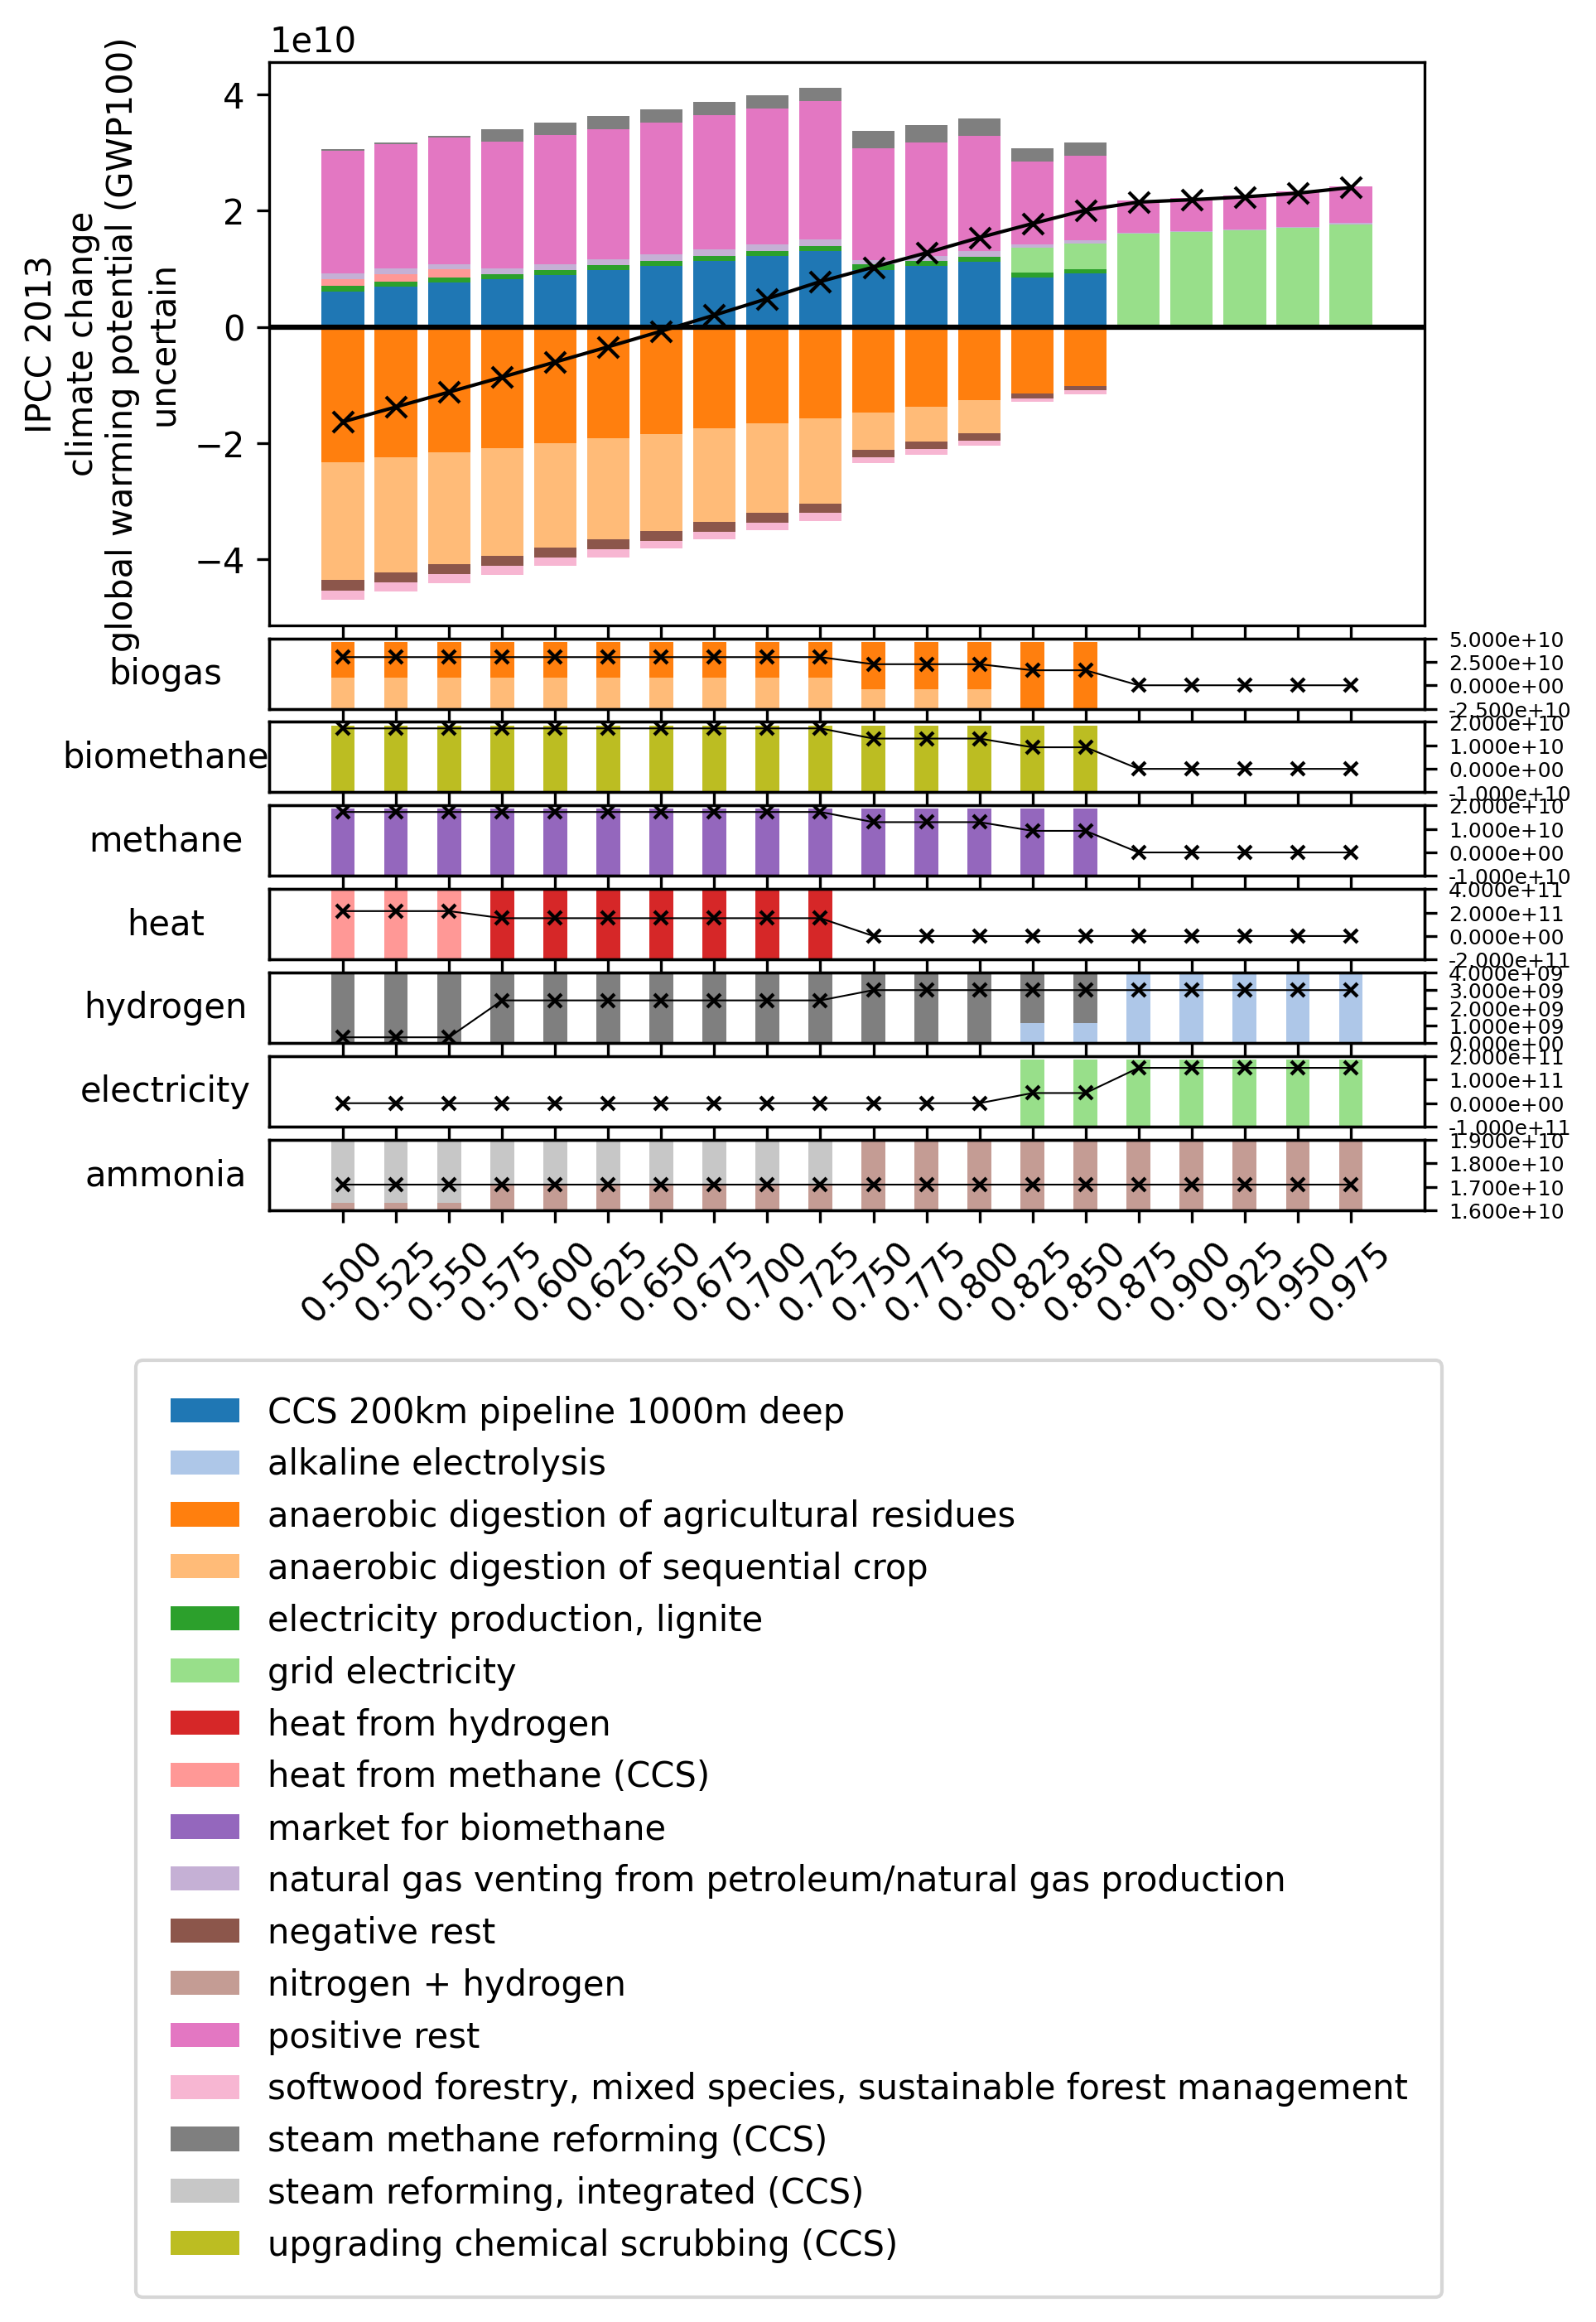

In [12]:
# Check if CC-Pareto results already exist
if check_file_exists(CC_PARETO_FILE):
    print(f"Loading existing CC-Pareto results from {CC_PARETO_FILE}...")
    cc_pareto_results = load_results(CC_PARETO_FILE)
else:
    print("Running CC-Pareto optimization...")
    
    # Define uncertainty strategies for CC formulation
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'minimum': 0.1, 'maximum': 0.8, 'uncertainty_type': 4},
                (81, 23537): {'loc': 0.002, 'minimum': 0.00057, 'maximum': 0.006, 'uncertainty_type': 5},
                (82, 23537): {'loc': 0.003, 'minimum': 0.00093, 'maximum': 0.009, 'uncertainty_type': 5},
                (716, 23537): {'loc': 0.023, 'minimum': 0.00663, 'maximum': 0.069, 'uncertainty_type': 5},
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=True,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Create CC formulation
    normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(
        CC_env_cost=True,
        CC_var_bounds=['upper_limit']
    )
    
    # Solve CC-Pareto problem using epsilon-constraint method
    lambda_epsilon_array = np.linspace(0.5, 1, 20, endpoint=False)
    results_CC = pulpo_worker.solve_CC_problem(
        lambda_epsilon_array, 
        normal_metadata_env_cost, 
        normal_metadata_var_bounds, 
        solver_name=SOLVER_NAME
    )
    
    # Package results
    cc_pareto_results = {
        'results_CC': results_CC,
        'lambda_epsilon_array': lambda_epsilon_array,
        'normal_metadata_env_cost': normal_metadata_env_cost,
        'normal_metadata_var_bounds': normal_metadata_var_bounds,
        'uncertainty_data': pulpo_worker.uncertainty_data
    }
    
    # Save results
    save_results(cc_pareto_results, CC_PARETO_FILE)
    
    print("✓ CC-Pareto optimization completed!")

# Display results summary
print("\nCC-Pareto Results Summary:")
print("-" * 60)
print(f"Generated {len(cc_pareto_results['results_CC'])} Pareto points")
print(f"Lambda-epsilon range: {cc_pareto_results['lambda_epsilon_array'][0]:.2f} to {cc_pareto_results['lambda_epsilon_array'][-1]:.2f}")

# Plot Pareto front
try:
    plots.plot_pareto_front(
        result_data_CC=cc_pareto_results['results_CC'], 
        cutoff_value=0.015, 
        method="\n".join(method.split("'")[1::2]), 
        process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
        bbox_to_anchor=(0.45, -3.),
        cmap_name='tab20',
        group_act_by='process'
    )
    print("✓ Pareto front plotted successfully!")
except Exception as e:
    print(f"Note: Could not plot Pareto front - {e}")
    print("Results are still saved and available for analysis.")

## 3. Monte Carlo Analysis - Custom Uncertainty Strategies

This section runs Monte Carlo simulations using custom uncertainty strategies with expert knowledge and bounds.

Loading existing MC results (strategies) from data/results/mc_uncertainty_strategies.pkl...
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

Analyzing MC results with custom strategies...
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

Analyzing MC results with custom strategies...


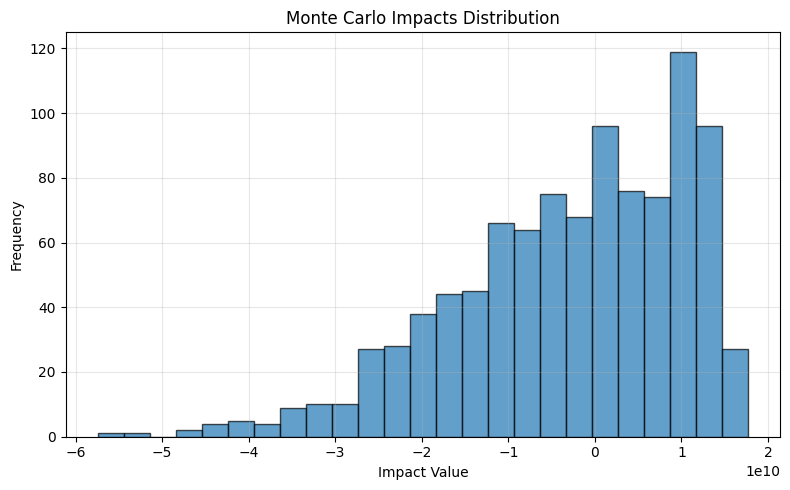


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    9.890000e+02
mean    -3.017549e+09
std      1.326767e+10
min     -5.739387e+10
25%     -1.142083e+10
50%     -7.068695e+08
75%      8.509336e+09
max      1.763963e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                                times_chosen  \
technology  process                                                            
ammonia     nitrogen + hydrogen | ammonia | RER                          950   
methane     market for biomethane | biomethane, 24 bar | RER             841   
biomethane  upgrading chemical scrubbing (CCS) | biomethane...           692   
electricity grid electricity | electricity, high voltage | RER           680   
hydrogen    alkaline electrolysis | hydrogen | RER                       680   
biogas      anaerobic digest

In [13]:
# Check if MC results with strategies already exist
if check_file_exists(MC_STRATEGIES_FILE):
    print(f"Loading existing MC results (strategies) from {MC_STRATEGIES_FILE}...")
    mc_strategies_results = load_results(MC_STRATEGIES_FILE)
else:
    print(f"Running Monte Carlo analysis with custom strategies ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Define uncertainty strategies
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'minimum': 0.1, 'maximum': 0.8, 'uncertainty_type': 4},
                (81, 23537): {'loc': 0.002, 'minimum': 0.00057, 'maximum': 0.006, 'uncertainty_type': 5},
                (82, 23537): {'loc': 0.003, 'minimum': 0.00093, 'maximum': 0.009, 'uncertainty_type': 5},
                (716, 23537): {'loc': 0.023, 'minimum': 0.00663, 'maximum': 0.069, 'uncertainty_type': 5},
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Run Monte Carlo
    mc_strategies_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS,
        seed=RANDOM_SEED,
        solver_name=SOLVER_NAME,
        options=None
    )
    
    # Save results
    save_results(mc_strategies_results, MC_STRATEGIES_FILE)
    
    print("✓ MC analysis with strategies completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with custom strategies...")
analysis_strategies = analyze_MC_results(mc_strategies_results, show_plot=True)

## 4. Monte Carlo Analysis - Fitted Normal Distributions

This section runs Monte Carlo simulations using fitted normal distributions transformed from the original uncertainty distributions.

Running Monte Carlo analysis with fitted normal distributions (1000 iterations)...
Creating Instance
Instance created
Instance created
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569) filtering resulted in 932 of 21178 exchanges (99.04% of total impact) and took 0.0 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 27 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 932
Deviation from LCA score: 0.009637170673559292
inventory (2648, 23569)

Sampling uncertainty draws: 100%|██████████| 1000/1000 [00:47<00:00, 20.99it/s]


Running 1000 Monte Carlo optimizations in parallel (n_jobs=-1).


Monte Carlo solve: 100%|██████████| 1000/1000 [1:35:23<00:00,  5.72s/it]



✓ Results saved to: data/results/mc_fitted_normal.pkl
✓ MC analysis with normal distributions completed!

Analyzing MC results with fitted normal distributions...


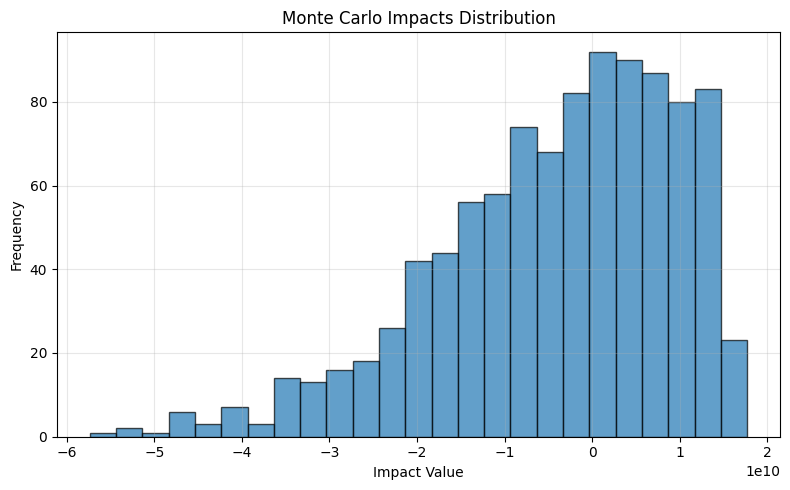


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    9.890000e+02
mean    -4.127648e+09
std      1.374486e+10
min     -5.736685e+10
25%     -1.264662e+10
50%     -1.704660e+09
75%      6.602370e+09
max      1.769798e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                                times_chosen  \
technology  process                                                            
ammonia     nitrogen + hydrogen | ammonia | RER                          944   
methane     market for biomethane | biomethane, 24 bar | RER             871   
biogas      anaerobic digestion of agricultural residues | ...           751   
biomethane  upgrading chemical scrubbing (CCS) | biomethane...           723   
hydrogen    steam methane reforming (CCS) | hydrogen | RER               664   
            alkaline electro

In [14]:
# Check if MC results with normal distributions already exist
if check_file_exists(MC_NORMAL_FILE):
    print(f"Loading existing MC results (normal) from {MC_NORMAL_FILE}...")
    mc_normal_results = load_results(MC_NORMAL_FILE)
else:
    print(f"Running Monte Carlo analysis with fitted normal distributions ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Define uncertainty strategies (same as before)
    unc_strategies = [
        processor.TriangularBoundInterpolationStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ecoinvent-3.10-cutoff',
            noise_interval={'min': 0.1, 'max': 0.1}
        ),
        processor.UniformBaseStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            upper_scaling_factor=0.5,
            lower_scaling_factor=0.5,
            noise_interval={'min': 0.2, 'max': 0.2}
        ),
        processor.ExpertKnowledgeStrategy(
            uncertain_param_type='If',
            uncertain_param_subgroup='ammonia',
            prob_metadata={
                (715, 23523): {'minimum': 0.1, 'maximum': 0.8, 'uncertainty_type': 4},
                (81, 23537): {'loc': 0.002, 'minimum': 0.00057, 'maximum': 0.006, 'uncertainty_type': 5},
                (82, 23537): {'loc': 0.003, 'minimum': 0.00093, 'maximum': 0.009, 'uncertainty_type': 5},
                (716, 23537): {'loc': 0.023, 'minimum': 0.00663, 'maximum': 0.069, 'uncertainty_type': 5},
            }
        )
    ]
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Transform distributions to normal
    pulpo_worker.uncertainty_data = processor.transform_to_normal(
        pulpo_worker.uncertainty_data,
        sample_size=100,
        plot_distribution=False
    )
    
    # Run Monte Carlo
    mc_normal_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS,
        seed=RANDOM_SEED,
        solver_name=SOLVER_NAME,
        options=None
    )
    
    # Save results
    save_results(mc_normal_results, MC_NORMAL_FILE)
    
    print("✓ MC analysis with normal distributions completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with fitted normal distributions...")
analysis_normal = analyze_MC_results(mc_normal_results, show_plot=True)

## 5. Monte Carlo Analysis - Ecoinvent Uncertainties Only (B and Q)

This section runs Monte Carlo simulations using only the original Ecoinvent uncertainty information (B and Q matrices), without custom strategies.

Running Monte Carlo analysis with Ecoinvent uncertainties only (1000 iterations)...
Creating Instance
Creating Instance
Instance created
Pre-sampling 1000 LCI matrix sets...
Instance created
Pre-sampling 1000 LCI matrix sets...


Sampling LCI matrices: 100%|██████████| 1000/1000 [27:20<00:00,  1.64s/it]


Solving 1000 Monte Carlo optimizations in parallel...
Running 1000 Monte Carlo optimizations in parallel (n_jobs=-1)...


Monte Carlo solve: 100%|██████████| 1000/1000 [1:35:48<00:00,  5.75s/it]



✓ Results saved to: data/results/mc_ecoinvent_only.pkl
✓ MC analysis with Ecoinvent uncertainties completed!

Analyzing MC results with Ecoinvent uncertainties only...


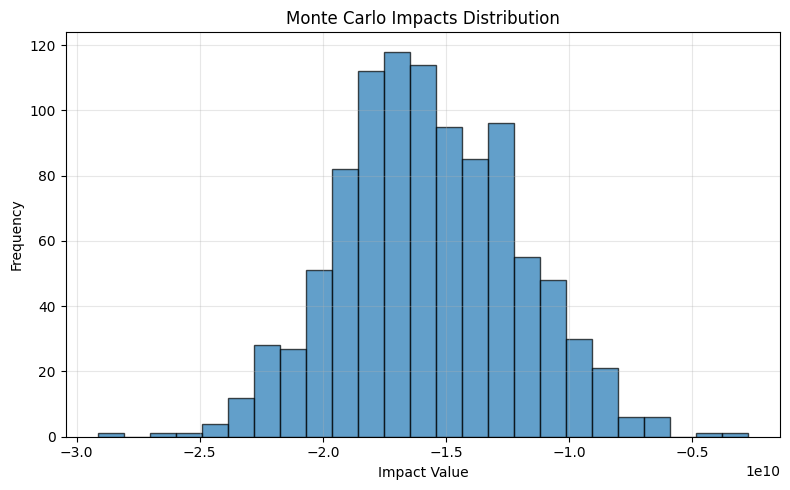


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    9.950000e+02
mean    -1.569682e+10
std      3.597979e+09
min     -2.912519e+10
25%     -1.811617e+10
50%     -1.592361e+10
75%     -1.310521e+10
max     -2.757335e+09
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
ammonia    nitrogen + hydrogen | ammonia | RER                          995   
           steam reforming, integrated (CCS) | ammonia | RER            995   
biogas     anaerobic digestion of agricultural residues | ...           995   
           anaerobic digestion of sequential crop | biogas...           995   
heat       heat from methane (CCS) | heat | RER                         995   
hydrogen   steam methane reforming 

In [15]:
# Check if MC results with ecoinvent only already exist
if check_file_exists(MC_ECOINVENT_FILE):
    print(f"Loading existing MC results (ecoinvent) from {MC_ECOINVENT_FILE}...")
    mc_ecoinvent_results = load_results(MC_ECOINVENT_FILE)
else:
    print(f"Running Monte Carlo analysis with Ecoinvent uncertainties only ({N_MC_ITERATIONS} iterations)...")
    
    # Re-instantiate problem for MC
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    # Run Monte Carlo using only B and Q matrices from Ecoinvent
    mc_ecoinvent_results = pulpo_worker.solve_MC(
        n_it=N_MC_ITERATIONS, 
        GAMS_PATH=False, 
        solver_name=SOLVER_NAME, 
        resample=('B', 'Q')
    )
    
    # Save results
    save_results(mc_ecoinvent_results, MC_ECOINVENT_FILE)
    
    print("✓ MC analysis with Ecoinvent uncertainties completed!")

# Analyze and visualize results
print("\nAnalyzing MC results with Ecoinvent uncertainties only...")
analysis_ecoinvent = analyze_MC_results(mc_ecoinvent_results, show_plot=True)

## 6. Comparative Analysis of Results

Compare the results from all three Monte Carlo approaches.

In [16]:
# Create comparative summary
print("\n" + "="*80)
print("COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES")
print("="*80)

comparison_data = {
    'Approach': [
        'Custom Strategies',
        'Fitted Normal',
        'Ecoinvent Only'
    ],
    'Mean Impact': [
        analysis_strategies['impact_stats']['mean'],
        analysis_normal['impact_stats']['mean'],
        analysis_ecoinvent['impact_stats']['mean']
    ],
    'Std Dev': [
        analysis_strategies['impact_stats']['std'],
        analysis_normal['impact_stats']['std'],
        analysis_ecoinvent['impact_stats']['std']
    ],
    'Min Impact': [
        analysis_strategies['impact_stats']['min'],
        analysis_normal['impact_stats']['min'],
        analysis_ecoinvent['impact_stats']['min']
    ],
    'Max Impact': [
        analysis_strategies['impact_stats']['max'],
        analysis_normal['impact_stats']['max'],
        analysis_ecoinvent['impact_stats']['max']
    ],
    'CV (%)': [
        (analysis_strategies['impact_stats']['std'] / analysis_strategies['impact_stats']['mean']) * 100,
        (analysis_normal['impact_stats']['std'] / analysis_normal['impact_stats']['mean']) * 100,
        (analysis_ecoinvent['impact_stats']['std'] / analysis_ecoinvent['impact_stats']['mean']) * 100
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))
print("\n" + "="*80)


COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES

          Approach   Mean Impact      Std Dev    Min Impact    Max Impact      CV (%)
Custom Strategies -3.017549e+09 1.326767e+10 -5.739387e+10  1.763963e+10 -439.683860
    Fitted Normal -4.127648e+09 1.374486e+10 -5.736685e+10  1.769798e+10 -332.994867
   Ecoinvent Only -1.569682e+10 3.597979e+09 -2.912519e+10 -2.757335e+09  -22.921709



## 7. Combined Visualization

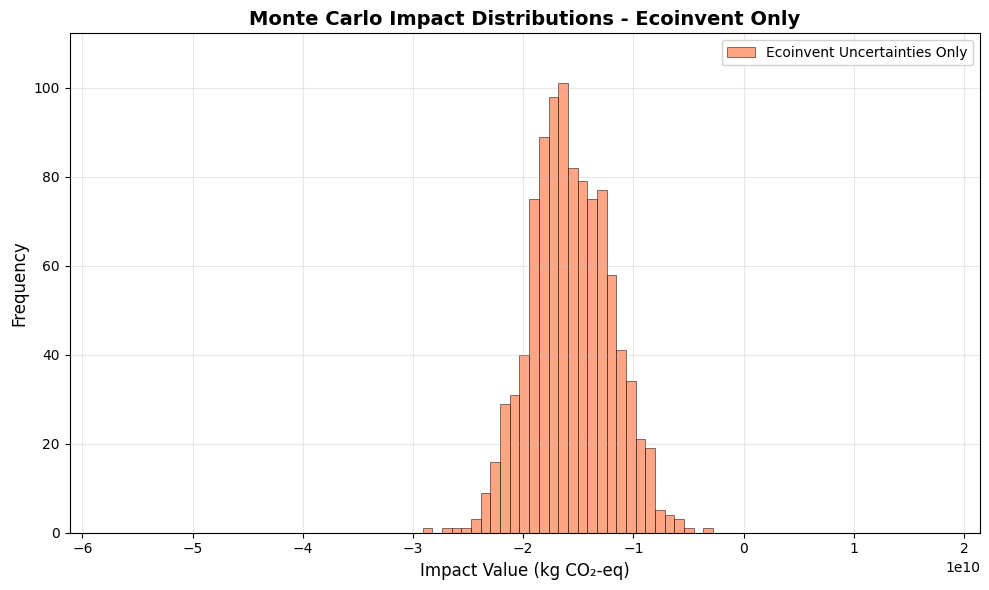

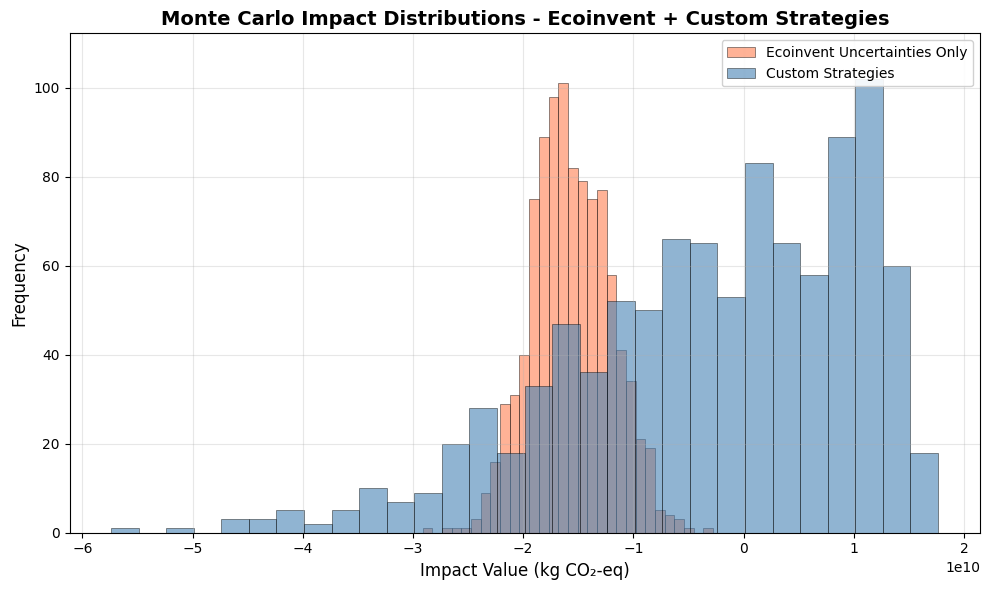

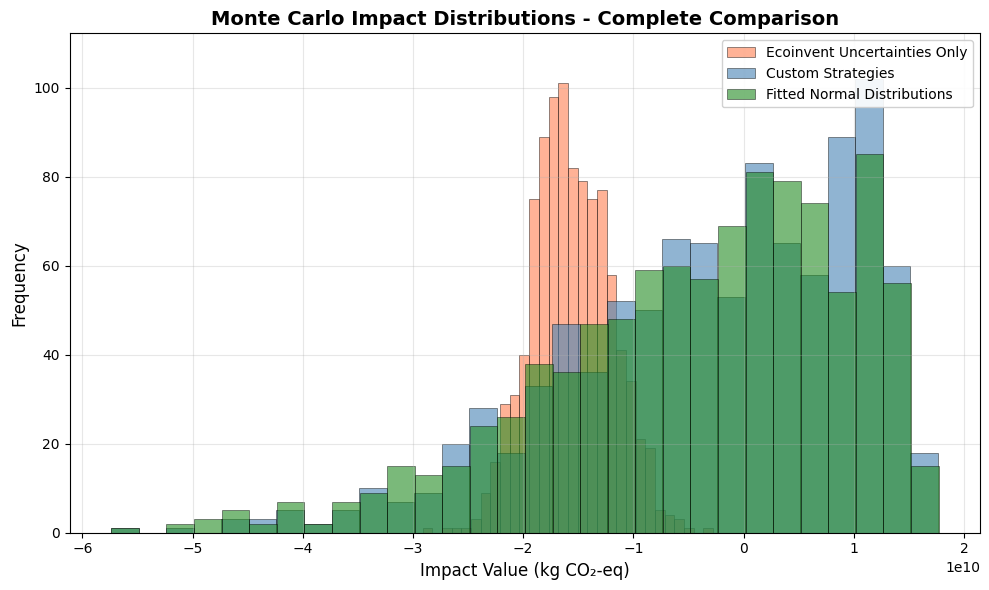


✓ Three progressive comparison plots saved:
  1. data/results/mc_comparison_1_ecoinvent.png
  2. data/results/mc_comparison_2_strategies.png
  3. data/results/mc_comparison_3_complete.png


In [19]:
# Calculate consistent axis ranges for all plots
all_values = np.concatenate([
    analysis_ecoinvent['impact_values'],
    analysis_strategies['impact_values'], 
    analysis_normal['impact_values']
])
x_min, x_max = all_values.min(), all_values.max()
x_range = x_max - x_min
x_min_plot = x_min - 0.05 * x_range
x_max_plot = x_max + 0.05 * x_range

# Calculate histogram to get consistent y-range
bins = 30
_, _, patches = plt.hist(all_values, bins=bins, alpha=0)
plt.close()  # Close the temporary plot

# Get y-range by calculating max frequency across all distributions
hist_eco, _ = np.histogram(analysis_ecoinvent['impact_values'], bins=bins)
hist_strat, _ = np.histogram(analysis_strategies['impact_values'], bins=bins)
hist_norm, _ = np.histogram(analysis_normal['impact_values'], bins=bins)
y_max = max(hist_eco.max(), hist_strat.max(), hist_norm.max())
y_max_plot = y_max * 1.1

# Figure 1: Ecoinvent Uncertainties Only
plt.figure(figsize=(10, 6))
plt.hist(analysis_ecoinvent['impact_values'], bins=bins, alpha=0.7, color='coral', 
         label='Ecoinvent Uncertainties Only', edgecolor='black', linewidth=0.5)
plt.title('Monte Carlo Impact Distributions - Ecoinvent Only', fontsize=14, fontweight='bold')
plt.xlabel('Impact Value (kg CO₂-eq)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(x_min_plot, x_max_plot)
plt.ylim(0, y_max_plot)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mc_comparison_1_ecoinvent.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Ecoinvent + Custom Strategies
plt.figure(figsize=(10, 6))
plt.hist(analysis_ecoinvent['impact_values'], bins=bins, alpha=0.6, color='coral', 
         label='Ecoinvent Uncertainties Only', edgecolor='black', linewidth=0.5)
plt.hist(analysis_strategies['impact_values'], bins=bins, alpha=0.6, color='steelblue', 
         label='Custom Strategies', edgecolor='black', linewidth=0.5)
plt.title('Monte Carlo Impact Distributions - Ecoinvent + Custom Strategies', fontsize=14, fontweight='bold')
plt.xlabel('Impact Value (kg CO₂-eq)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(x_min_plot, x_max_plot)
plt.ylim(0, y_max_plot)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mc_comparison_2_strategies.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: All Three Distributions
plt.figure(figsize=(10, 6))
plt.hist(analysis_ecoinvent['impact_values'], bins=bins, alpha=0.6, color='coral', 
         label='Ecoinvent Uncertainties Only', edgecolor='black', linewidth=0.5)
plt.hist(analysis_strategies['impact_values'], bins=bins, alpha=0.6, color='steelblue', 
         label='Custom Strategies', edgecolor='black', linewidth=0.5)
plt.hist(analysis_normal['impact_values'], bins=bins, alpha=0.6, color='forestgreen', 
         label='Fitted Normal Distributions', edgecolor='black', linewidth=0.5)
plt.title('Monte Carlo Impact Distributions - Complete Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Impact Value (kg CO₂-eq)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(x_min_plot, x_max_plot)
plt.ylim(0, y_max_plot)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/mc_comparison_3_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Three progressive comparison plots saved:")
print(f"  1. {RESULTS_DIR}/mc_comparison_1_ecoinvent.png")
print(f"  2. {RESULTS_DIR}/mc_comparison_2_strategies.png") 
print(f"  3. {RESULTS_DIR}/mc_comparison_3_complete.png")

## 8. Summary and Conclusions

In [18]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nTotal iterations per approach: {N_MC_ITERATIONS}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Solver: {SOLVER_NAME}")
print(f"\nAll results saved to: {RESULTS_DIR}")
print("\nFiles generated:")
print(f"  1. {CC_PARETO_FILE}")
print(f"  2. {MC_STRATEGIES_FILE}")
print(f"  3. {MC_NORMAL_FILE}")
print(f"  4. {MC_ECOINVENT_FILE}")
print(f"  5. {RESULTS_DIR}/mc_comparison.png")
print("\n" + "="*80)
print("\n✓ Notebook execution completed successfully!")


ANALYSIS COMPLETE

Total iterations per approach: 1000
Random seed: 888
Solver: gurobi

All results saved to: data/results

Files generated:
  1. data/results/cc_pareto_results.pkl
  2. data/results/mc_uncertainty_strategies.pkl
  3. data/results/mc_fitted_normal.pkl
  4. data/results/mc_ecoinvent_only.pkl
  5. data/results/mc_comparison.png


✓ Notebook execution completed successfully!
